Processing Index 1 (0.03 MHz Target)...
Processing Index 2 (35 MHz Target)...
Processing Index 3 (128 MHz Target)...
Processing Index 4 (255 MHz Target)...
Processing Index 5 (300 MHz Target)...


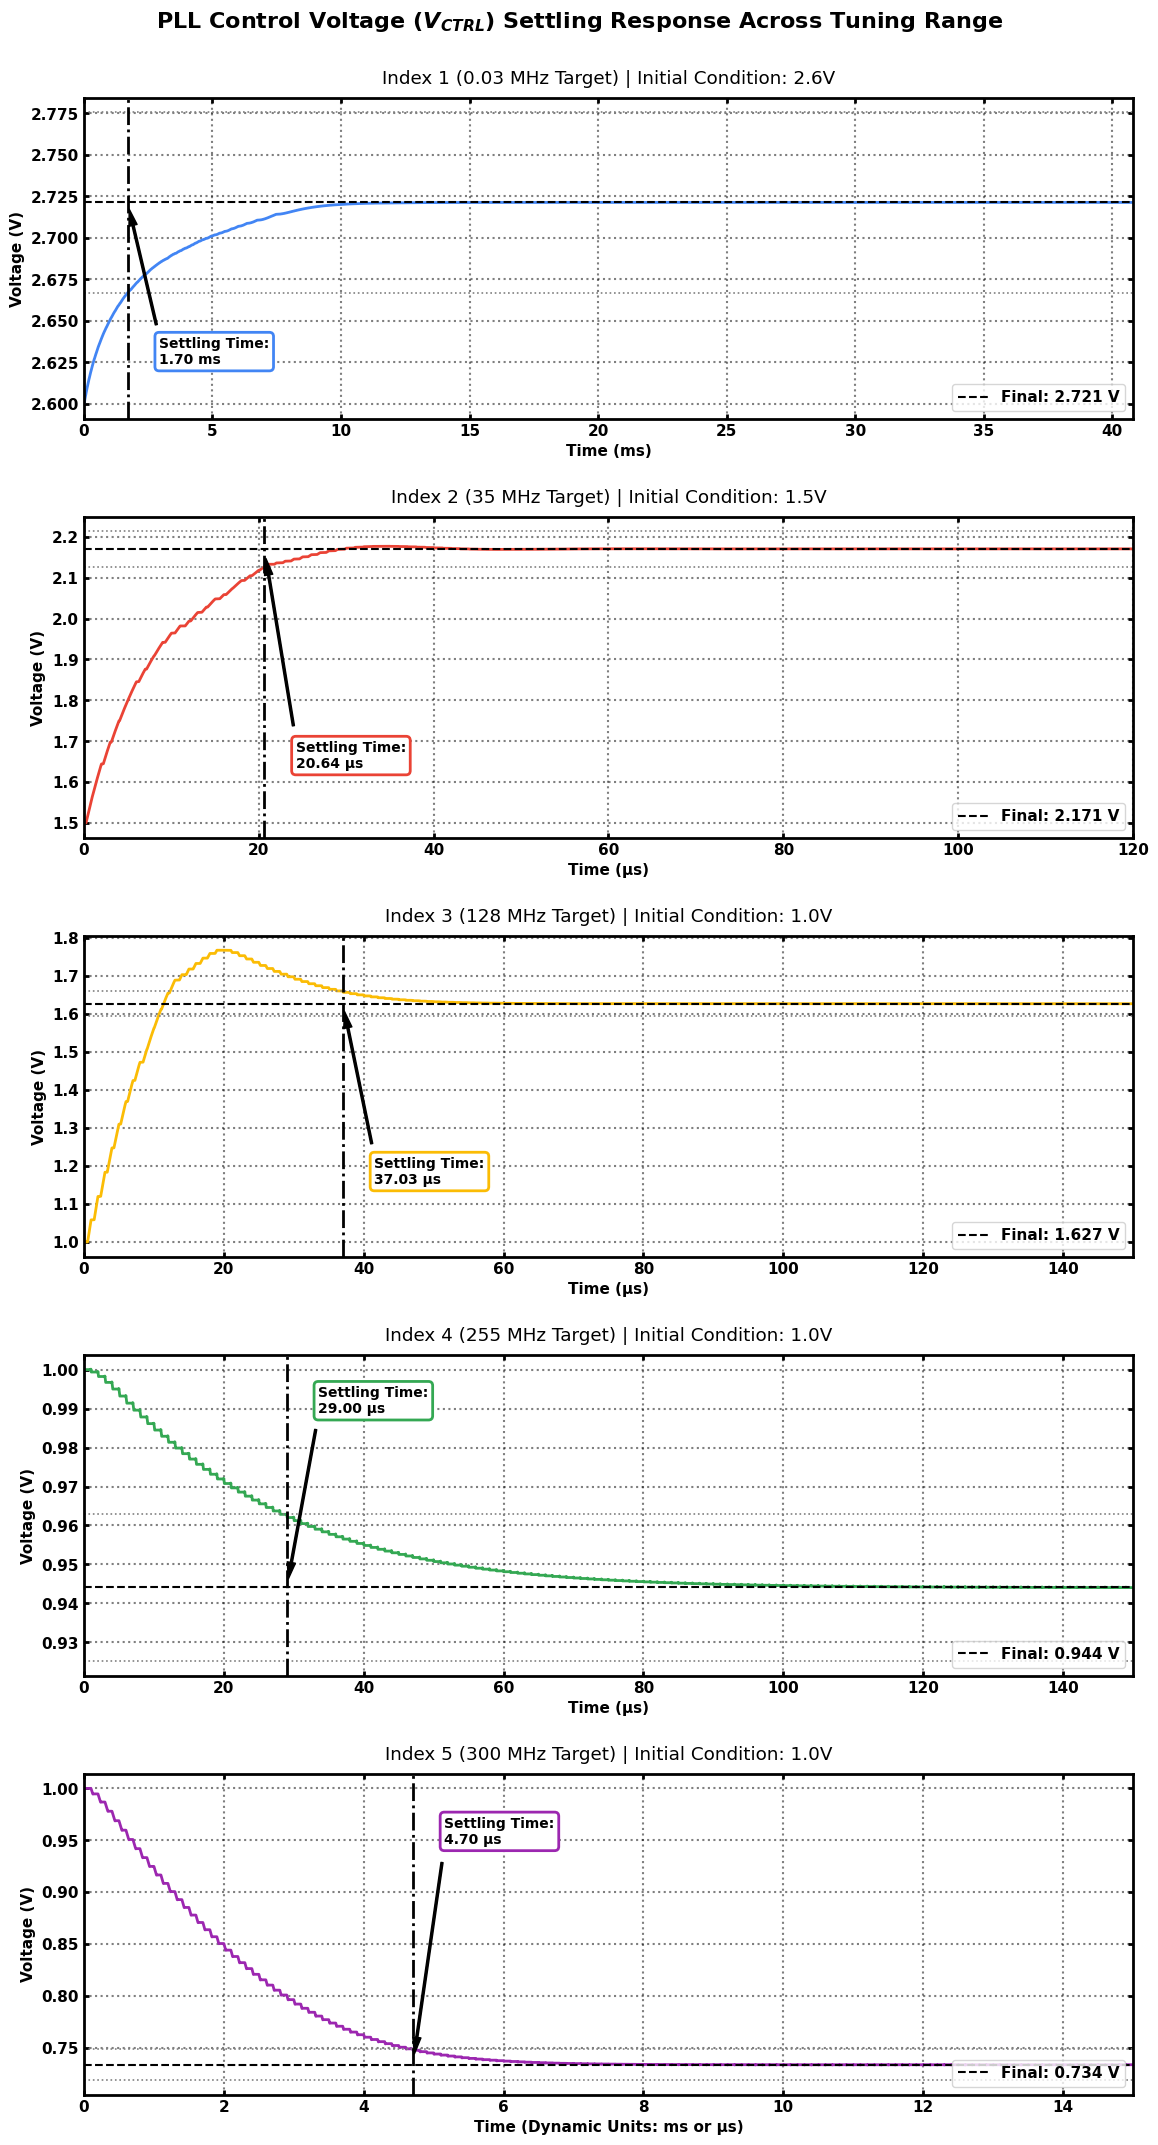

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# ==========================================
# 1. Configuration & Multi-File Setup
# ==========================================
# Map the file paths, labels, and initial conditions for each of the 5 testbenches
tb_configs = [
    {
        'file': '../sim_data/tb1_3.txt', 
        'label': 'Index 1 (0.03 MHz Target)', 
        'ic': 2.6, 
        'color': '#4285F4' # Blue
    },
    {
        'file': '../sim_data/tb2_7.txt', 
        'label': 'Index 2 (35 MHz Target)', 
        'ic': 1.50, 
        'color': '#EA4335' # Red
    },
    {
        'file': '../sim_data/tb3_4.txt', 
        'label': 'Index 3 (128 MHz Target)', 
        'ic': 1.00, 
        'color': '#FBBC05' # Yellow
    },
    {
        'file': '../sim_data/tb4.txt', 
        'label': 'Index 4 (255 MHz Target)', 
        'ic': 1.00, 
        'color': '#34A853' # Green
    },
    {
        'file': '../sim_data/tb5_3.txt', 
        'label': 'Index 5 (300 MHz Target)', 
        'ic': 1.00, 
        'color': '#9C27B0' # Purple
    }
]

VCTRL_COLUMN_NAME = 'vctrl'
TIME_COLUMN_NAME = 'time'
ERROR_BAND_PERCENT = 2.0 

# ==========================================
# 2. Global Plotting Style
# ==========================================
plt.rcParams.update({
    'axes.linewidth': 2,
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'font.size': 11
})

fig, axes = plt.subplots(5, 1, figsize=(12, 22))
fig.suptitle('PLL Control Voltage ($V_{CTRL}$) Settling Response Across Tuning Range', fontsize=16, fontweight='bold', y=0.98)

# ==========================================
# 3. Data Processing & Plotting Loop
# ==========================================
for i, config in enumerate(tb_configs):
    ax = axes[i]
    file_path = config['file']
    label = config['label']
    ic_val = config['ic']
    color = config['color']
    
    if not os.path.exists(file_path):
        ax.text(0.5, 0.5, f"FILE NOT FOUND:\n{file_path}",
                horizontalalignment='center', verticalalignment='center', 
                color='red', transform=ax.transAxes, weight='bold')
        ax.set_title(f"{label} | Initial Condition: {ic_val}V")
        continue

    print(f"Processing {label}...")
    
    # --- OPTIMIZATION 1: Sniff the header to find exact column indices ---
    with open(file_path, 'r') as f:
        header = f.readline().strip().split()
    
    header_lower = [h.lower() for h in header]
    
    if TIME_COLUMN_NAME not in header_lower or VCTRL_COLUMN_NAME not in header_lower:
        print(f"ERROR: Missing time/vctrl columns in {file_path}")
        continue
        
    time_idx = header_lower.index(TIME_COLUMN_NAME)
    vctrl_idx = header_lower.index(VCTRL_COLUMN_NAME)

    # --- OPTIMIZATION 2: Load ONLY the two required columns using the fast C-engine ---
    df = pd.read_csv(file_path, sep=r'\s+', usecols=[time_idx, vctrl_idx])
    
    # Standardize column names
    df.columns = [TIME_COLUMN_NAME, VCTRL_COLUMN_NAME]

    # --- OPTIMIZATION 3: Downsample by a factor of 50 to prevent Matplotlib freezing ---
    df = df.iloc[::50, :]

    t = df[TIME_COLUMN_NAME].values
    vctrl = df[VCTRL_COLUMN_NAME].values

    # --- CUSTOM DATA TRUNCATION ---
    if "Index 1" in label:
        # Slice Index 1 to drop everything after 40.8 ms
        valid_mask = t <= 40.8e-3
        t = t[valid_mask]
        vctrl = vctrl[valid_mask]
        
    if "Index 5" in label:
        # Slice Index 5 to drop everything after 15 us
        valid_mask = t <= 15.0e-6
        t = t[valid_mask]
        vctrl = vctrl[valid_mask]

    # Determine optimal time scale (ms vs us)
    max_time = t[-1]
    if max_time > 1e-3:
        t_scaled = t * 1e3
        time_unit = "ms"
    else:
        t_scaled = t * 1e6
        time_unit = "µs"

    # Steady-state extraction (last 10% of simulation)
    steady_state_slice = max(int(len(vctrl) * 0.1), 1)
    v_final = np.mean(vctrl[-steady_state_slice:])

    # Error band calculation
    error_margin = v_final * (ERROR_BAND_PERCENT / 100.0)
    upper_bound = v_final + error_margin
    lower_bound = v_final - error_margin

    # Reverse search algorithm for settling time
    out_of_bounds_indices = np.where((vctrl > upper_bound) | (vctrl < lower_bound))[0]
    
    is_settled = False
    if len(out_of_bounds_indices) > 0:
        settling_idx = min(out_of_bounds_indices[-1] + 1, len(t) - 1)
        settling_time_scaled = t_scaled[settling_idx]
        is_settled = True
    
    # Plotting the trace
    ax.plot(t_scaled, vctrl, color=color, linewidth=2)
    ax.axhline(v_final, color='black', linestyle='--', linewidth=1.5, label=f'Final: {v_final:.3f} V')
    ax.axhline(upper_bound, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(lower_bound, color='gray', linestyle=':', linewidth=1.2)

    # Annotations
    ax.set_title(f"{label} | Initial Condition: {ic_val}V", pad=10)
    ax.set_ylabel('Voltage (V)')
    ax.grid(True, linestyle=':', linewidth=1.5, color='black', alpha=0.5)
    
    if is_settled:
        ax.axvline(settling_time_scaled, color='black', linestyle='-.', linewidth=2)
        bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec=color, lw=2)
        
        # Position the text box dynamically to avoid overlapping the trace
        y_text_pos = np.min(vctrl) + (np.max(vctrl) - np.min(vctrl)) * 0.2
        if v_final < np.mean([np.min(vctrl), np.max(vctrl)]):
            y_text_pos = np.max(vctrl) - (np.max(vctrl) - np.min(vctrl)) * 0.2

        ax.annotate(f'Settling Time:\n{settling_time_scaled:.2f} {time_unit}',
                    xy=(settling_time_scaled, v_final),
                    xytext=(settling_time_scaled + (t_scaled[-1] * 0.03), y_text_pos),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                    bbox=bbox_props, fontsize=10, fontweight='bold')

    # Formatting axes
    ax.set_xlim([0, t_scaled[-1]])
    if i == 4:
        ax.set_xlabel('Time (Dynamic Units: ms or µs)')
    else:
        ax.set_xlabel(f'Time ({time_unit})')
        
    ax.legend(loc='lower right')

plt.tight_layout(pad=2.0)
plt.subplots_adjust(top=0.94) # Make room for the main title
plt.show()

Processing Index 5 (300 MHz Target)...


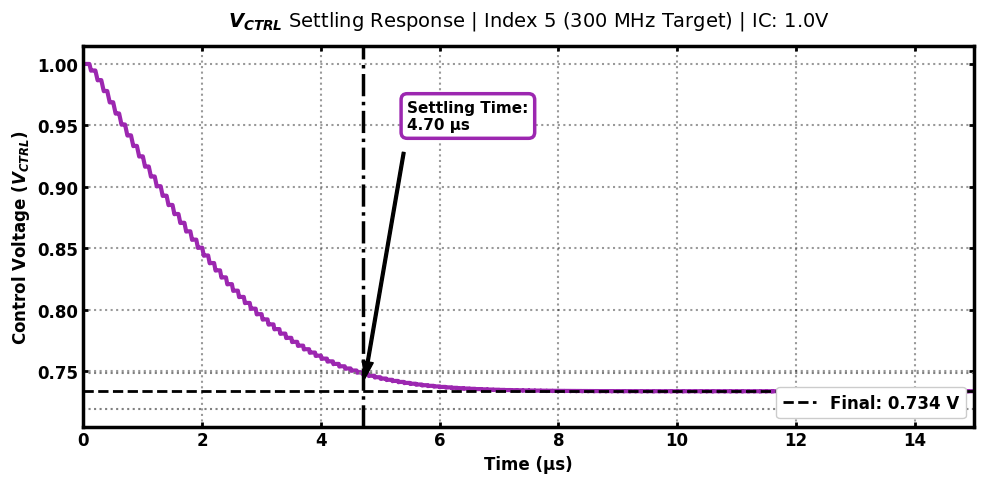

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# ==========================================
# 1. Configuration
# ==========================================
file_path = '../sim_data/tb5_3.txt'
label = 'Index 5 (300 MHz Target)'
ic_val = 1.00
color = '#9C27B0' # Purple

VCTRL_COLUMN_NAME = 'vctrl'
TIME_COLUMN_NAME = 'time'
ERROR_BAND_PERCENT = 2.0 

# ==========================================
# 2. Global Plotting Style
# ==========================================
plt.rcParams.update({
    'axes.linewidth': 2.5,
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'font.size': 12
})

# Wide aspect ratio (10x5) ideal for PowerPoint
fig, ax = plt.subplots(figsize=(10, 5))

# ==========================================
# 3. Data Processing & Plotting
# ==========================================
if not os.path.exists(file_path):
    print(f"FILE NOT FOUND: {file_path}")
    sys.exit()

print(f"Processing {label}...")

# --- OPTIMIZATION 1: Sniff the header ---
with open(file_path, 'r') as f:
    header = f.readline().strip().split()

header_lower = [h.lower() for h in header]

if TIME_COLUMN_NAME not in header_lower or VCTRL_COLUMN_NAME not in header_lower:
    print(f"ERROR: Missing time/vctrl columns in {file_path}")
    sys.exit()
    
time_idx = header_lower.index(TIME_COLUMN_NAME)
vctrl_idx = header_lower.index(VCTRL_COLUMN_NAME)

# --- OPTIMIZATION 2: Load ONLY required columns ---
df = pd.read_csv(file_path, sep=r'\s+', usecols=[time_idx, vctrl_idx])
df.columns = [TIME_COLUMN_NAME, VCTRL_COLUMN_NAME]

# --- OPTIMIZATION 3: Downsample ---
df = df.iloc[::50, :]

t = df[TIME_COLUMN_NAME].values
vctrl = df[VCTRL_COLUMN_NAME].values

# --- CUSTOM DATA TRUNCATION ---
# Slice Index 5 to drop everything after 15 us
valid_mask = t <= 15.0e-6
t = t[valid_mask]
vctrl = vctrl[valid_mask]

# Determine optimal time scale
t_scaled = t * 1e6
time_unit = "µs"

# Steady-state extraction (last 10% of simulation)
steady_state_slice = max(int(len(vctrl) * 0.1), 1)
v_final = np.mean(vctrl[-steady_state_slice:])

# Error band calculation
error_margin = v_final * (ERROR_BAND_PERCENT / 100.0)
upper_bound = v_final + error_margin
lower_bound = v_final - error_margin

# Reverse search algorithm for settling time
out_of_bounds_indices = np.where((vctrl > upper_bound) | (vctrl < lower_bound))[0]

is_settled = False
if len(out_of_bounds_indices) > 0:
    settling_idx = min(out_of_bounds_indices[-1] + 1, len(t) - 1)
    settling_time_scaled = t_scaled[settling_idx]
    is_settled = True

# Plotting the trace
ax.plot(t_scaled, vctrl, color=color, linewidth=3)
ax.axhline(v_final, color='black', linestyle='--', linewidth=2, label=f'Final: {v_final:.3f} V')
ax.axhline(upper_bound, color='gray', linestyle=':', linewidth=1.5)
ax.axhline(lower_bound, color='gray', linestyle=':', linewidth=1.5)

# Annotations
ax.set_title(
    fr"$V_{{CTRL}}$ Settling Response | {label} | IC: {ic_val}V",
    pad=15,
    fontsize=14
)
ax.set_ylabel('Control Voltage ($V_{CTRL}$)')
ax.grid(True, linestyle=':', linewidth=1.5, color='black', alpha=0.4)

if is_settled:
    ax.axvline(settling_time_scaled, color='black', linestyle='-.', linewidth=2.5)
    bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec=color, lw=2.5)
    
    # Position the text box dynamically
    y_text_pos = np.min(vctrl) + (np.max(vctrl) - np.min(vctrl)) * 0.2
    if v_final < np.mean([np.min(vctrl), np.max(vctrl)]):
        y_text_pos = np.max(vctrl) - (np.max(vctrl) - np.min(vctrl)) * 0.2

    ax.annotate(f'Settling Time:\n{settling_time_scaled:.2f} {time_unit}',
                xy=(settling_time_scaled, v_final),
                xytext=(settling_time_scaled + (t_scaled[-1] * 0.05), y_text_pos),
                arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
                bbox=bbox_props, fontsize=11, fontweight='bold')

# Formatting axes
ax.set_xlim([0, t_scaled[-1]])
ax.set_xlabel(f'Time ({time_unit})')
ax.legend(loc='lower right', framealpha=1)

plt.tight_layout()

# Save the figure automatically with a transparent background
plt.savefig('tb5_optimized_settling.png', dpi=300, transparent=True)
plt.show()